Maybe I should normalize the input and output of LSTM
Instead of predicting the return, maybe I should predict if it is a positive return or negative return. Probably I can get a higher investment return.

In [1810]:
pip install ta

In [1811]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import asyncio
import yfinance as yf
import seaborn as sns
import ta

In [1812]:
import pandas_datareader as pdr
cpi = pdr.DataReader('CPIAUCSL', 'fred', start='2016-06-15')
print(cpi)

            CPIAUCSL
DATE                
2016-07-01   240.101
2016-08-01   240.545
2016-09-01   241.176
2016-10-01   241.741
2016-11-01   242.026
...              ...
2025-10-01       NaN
2025-11-01   325.063
2025-12-01   326.031
2026-01-01   326.588
2026-02-01   327.460

[116 rows x 1 columns]


In [1899]:
#Configurations
numberOfPreviousDaysConsidered = 10

training_start_time = '2016-06-15 00:00:00-05:00' #longer period
training_end_time = '2024-02-01 00:00:00-05:00' #longer period
# training_start_time = '2024-09-30 00:00:00-05:00' #shorter period
# training_end_time = '2025-09-30 00:00:00-05:00' #shorter period
# listOfTickersForTraining = ["TSLA", "MSFT", "META", "NVDA", "AAPL", "AMZN", "ORCL", "NFLX"]
listOfTickersForTraining = ["TSLA"]
periodOfData = '11y'

# inputColumns = ['Daily Return']
inputColumns = ['Daily Return', 'Daily Volume Change', 'S&P 500 Daily Return', 'S&P 500 Daily Volume Change','RSI', 'mband', 'MACD']
# inputColumns = ['Daily Return', 'Daily Volume Change','RSI', 'mband', 'MACD']

# inputColumns = ['Daily Return', 'Daily Volume Change', 'S&P 500 Daily Volume Change']

testing_start_time = '2024-02-01 00:00:00-05:00' #longer period
testing_end_time = '2026-01-09 00:00:00-05:00' #longer period
# testing_start_time = '2025-08-16 00:00:00-05:00' #shorter period #should make this 30 trading days earlier so that can get last 30 days of data
# testing_end_time = '2025-12-31 00:00:00-05:00' #shorter period
# listOfTickersForTesting = ["TSLA", "MSFT", "META", "NVDA", "AAPL", "AMZN", "ORCL", "NFLX"]
listOfTickersForTesting = ["NFLX"] #FOR_TESTING: change and run this cell again for testing on different companies

batch_size= 16
epochs = 500
patience = 15
LR_SCHEDULE = [
    # (epoch to start, learning rate) tuples
    (0, 0.0001),
]


/usr/local/lib/python3.12/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/tmp/ipykernel_9545/3155961779.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  training_df_stock['lband'] = (indicator_bb.bollinger_lband()-training_df_stock['Close'])/training_df_stock['Close']
/tmp/ipykernel_9545/3155961779.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

999
921
IQR value for column Daily Return is: 0.035813505011225905
IQR value for column Daily Volume Change is: 0.38873359527798446
IQR value for column S&P 500 Daily Return is: 0.009627833206920844
IQR value for column S&P 500 Daily Volume Change is: 0.1454561399847494
IQR value for column RSI is: 0.18650994434494145
IQR value for column mband is: 0.1018597219988064
IQR value for column MACD is: 0.051605691196827765


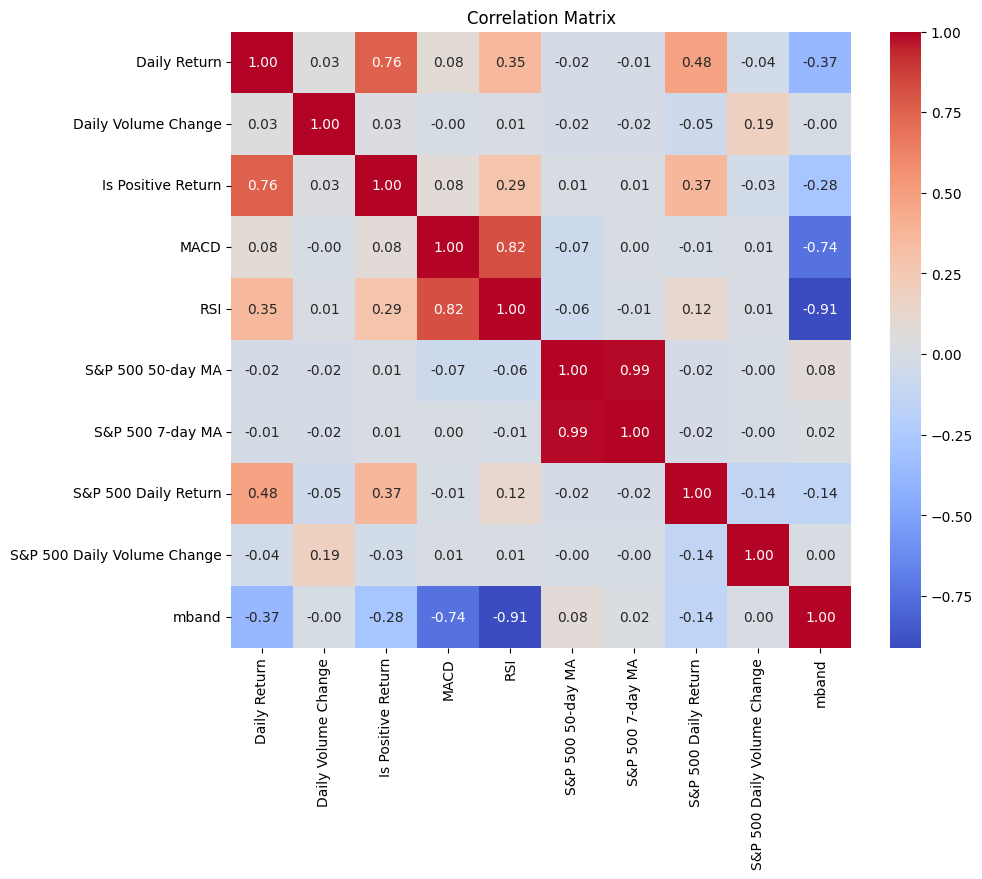

In [1814]:
def replaceWithCapOrFloor(x, cap, floor):
  if x > cap:
    return cap
  elif x < floor:
    return floor
  else:
    return x

def removeOutliers(data, col):
    Q3 = np.quantile(data[col], 0.75)
    Q1 = np.quantile(data[col], 0.25)
    IQR = Q3 - Q1

    print("IQR value for column %s is: %s" % (col, IQR))

    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR
    return data[col].apply(replaceWithCapOrFloor, args=(upper_range, lower_range))

#change this later, this wont work coz you are mixing it for example R0,n R1,1 R1,2 then you are using return of 2 stocks to predict the price of 1 stock. Therefore, it wont work.
training_df_list = []
for ticker in listOfTickersForTraining:
  dat = yf.Ticker(ticker)
  training_df_stock = dat.history(period= periodOfData).loc[training_start_time:training_end_time] #longer period
  training_df_stock['7-day MA'] = training_df_stock['Close'].rolling(window=7).mean()
  training_df_stock['50-day MA'] = training_df_stock['Close'].rolling(window=50).mean()
  training_df_stock['Daily Return'] = training_df_stock['Close'].pct_change()
  training_df_stock['Is Positive Return'] = training_df_stock['Daily Return'] >=0
  training_df_stock['Daily Volume Change'] = training_df_stock['Volume'].pct_change()
  training_df_stock['Ticker'] = ticker
  training_df_stock['Date'] = training_df_stock.index
  ta_indicator_applier = ta.add_all_ta_features(
    training_df_stock,
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True
  )
  training_df_stock['RSI'] = ta.momentum.rsi(training_df_stock['Close'], window=14)/100
  indicator_bb = ta.volatility.BollingerBands(close=training_df_stock["Close"], window=20, window_dev=2)
  training_df_stock['mband'] = (indicator_bb.bollinger_mavg()-training_df_stock['Close'])/training_df_stock['Close']
  training_df_stock['hband'] = (indicator_bb.bollinger_hband()-training_df_stock['Close'])/training_df_stock['Close']
  training_df_stock['lband'] = (indicator_bb.bollinger_lband()-training_df_stock['Close'])/training_df_stock['Close']
  training_df_stock['MACD'] = ta.trend.MACD(training_df_stock['Close'], window_slow = 26, window_fast = 12, window_sign = 9).macd()/training_df_stock['Close']
  # print(training_df_stock.head())
  columns_to_keep = ['Daily Return', 'Is Positive Return', 'Daily Volume Change', 'Ticker', 'Date', 'RSI', 'mband', 'MACD']
  # Use .loc to select all rows (:) and only columns where the mask is True
  training_df_stock = training_df_stock.loc[:, columns_to_keep]
  # print(training_df_stock.head())
  print(len(training_df_stock[training_df_stock['Is Positive Return']==True]))
  print(len(training_df_stock[training_df_stock['Is Positive Return']==False]))
  # training_df_stock= training_df_stock['Daily Return', 'Is Positive Return', 'Daily Volume Change', 'Ticker', 'Date', 'RSI', 'mband', 'hband', 'lband', 'MACD']
  training_df_list.append(training_df_stock.iloc[1:])
  # income_stat = dat.get_income_stmt(freq = 'quarterly')
  # print(income_stat)
  # print(training_df_stock)


#change this later, this wont work coz you are mixing it for example R0,n R1,1 R1,2 then you are using return of 2 stocks to predict the price of 1 stock. Therefore, it wont work.
index_ticker = "^GSPC"
dat = yf.Ticker(index_ticker)
training_df_index_raw = dat.history(period=periodOfData).loc[training_start_time:training_end_time]
training_df_index_processed = pd.DataFrame()
training_df_index_processed['S&P 500 7-day MA'] = training_df_index_raw['Close'].rolling(window=7).mean()
training_df_index_processed['S&P 500 50-day MA'] = training_df_index_raw['Close'].rolling(window=50).mean()
training_df_index_processed['S&P 500 Daily Return'] = training_df_index_raw['Close'].pct_change()
training_df_index_processed['S&P 500 Daily Volume Change'] = training_df_index_raw['Volume'].pct_change()
training_df_index_processed = training_df_index_processed.iloc[26:] #TODO: skipping determined by the window_slow of MACD, move it to configuration cells later

for i in range(len(training_df_list)):
  training_df_list[i] = pd.merge(training_df_list[i], training_df_index_processed, left_index=True, right_index=True)
  for column in inputColumns:
    # print(f'Before removing outlier: \nmin: {training_df_list[i][column].min()}\nmax: {training_df_list[i][column].max()}')
    training_df_list[i][column] = removeOutliers(training_df_list[i], column) #remove outliers
    # print(f'After removing outlier: \nmin: {training_df_list[i][column].min()}\nmax: {training_df_list[i][column].max()}')

  spearman_corr = training_df_list[i]['S&P 500 Daily Return'].corr(training_df_list[i]['Daily Return'], method='spearman')
  kendall_corr = training_df_list[i]['S&P 500 Daily Return'].corr(training_df_list[i]['Daily Return'], method='kendall')
  # print(training_df_list[i]['Ticker'][0])
  correlation_matrix = training_df_list[i][training_df_list[i].columns.difference(['Ticker', 'Date', 'Close'])].corr()
  plt.figure(figsize=(10, 8))
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
  plt.title('Correlation Matrix')
  plt.show()
  # print(training_df_list[i])

## Should add a column and sort by date so that the chronological order of the testing data wont be affected when there are more than one stock in training data:

In [1815]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
      temp = []
      for j in range(i, i + look_back):
        columnsOfDatasetUsed = []
        for column in inputColumns:
          columnsOfDatasetUsed.append(dataset[column][j])
        temp.append(columnsOfDatasetUsed)
      dataX.append(temp)
      ###regression###
      # dataY.append(dataset['Daily Return'][i + look_back])
      ###regression###

      ###binary classification###
      dataY.append(dataset['Is Positive Return'][i + look_back])
      ###binary classification###
    return np.array(dataX), np.array(dataY)

In [1816]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

X, Y = ([], [])
count = 0
for dataframe in training_df_list:
  x, y = create_dataset(dataframe, look_back=numberOfPreviousDaysConsidered)
  if count == 0:
    X = x
    Y = y
    print("first branch")
  else:
    X = np.append(X, x, axis=0)
    Y = np.append(Y, y)
    print("second branch")
  count+=1

print(X.shape)
print(Y.shape)

inputScaler = StandardScaler()
trainX = inputScaler.fit_transform(X.reshape(-1,len(inputColumns))).reshape(X.shape)
outputScaler = StandardScaler()

###regression###
# trainY = outputScaler.fit_transform(Y.reshape(-1,1)).reshape(Y.shape)
###regression###

###binary classification###
trainY = Y
###binary classification###


# trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)

/tmp/ipykernel_9545/977969221.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  columnsOfDatasetUsed.append(dataset[column][j])
/tmp/ipykernel_9545/977969221.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dataY.append(dataset['Is Positive Return'][i + look_back])


first branch
(1884, 10, 7)
(1884,)


In [1900]:
#FOR_TESTING: change and run this cell again for testing on different companies
#change this later, this wont work coz you are mixing it for example R0,n R1,1 R1,2 then you are using return of 2 stocks to predict the price of 1 stock. Therefore, it wont work.
testing_df_list = []
for ticker in listOfTickersForTesting:
  dat = yf.Ticker(ticker)
  testing_df_stock = dat.history(period=periodOfData).loc[testing_start_time:testing_end_time]  #longer period
  testing_df_stock['7-day MA'] = testing_df_stock['Close'].rolling(window=7).mean()
  testing_df_stock['50-day MA'] = testing_df_stock['Close'].rolling(window=50).mean()
  testing_df_stock['Daily Return'] = testing_df_stock['Close'].pct_change()
  testing_df_stock['Is Positive Return'] = testing_df_stock['Daily Return'] >=0
  testing_df_stock['Daily Volume Change'] = testing_df_stock['Volume'].pct_change()
  testing_df_stock['Ticker'] = ticker
  testing_df_stock['Date'] = testing_df_stock.index
  ta_indicator_applier = ta.add_all_ta_features(
    testing_df_stock,
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True
  )
  testing_df_stock['RSI'] = ta.momentum.rsi(testing_df_stock['Close'], window=14)/100
  indicator_bb = ta.volatility.BollingerBands(close=testing_df_stock["Close"], window=20, window_dev=2)
  testing_df_stock['mband'] = (indicator_bb.bollinger_mavg()-testing_df_stock['Close'])/testing_df_stock['Close']
  testing_df_stock['hband'] = (indicator_bb.bollinger_hband()-testing_df_stock['Close'])/testing_df_stock['Close']
  testing_df_stock['lband'] = (indicator_bb.bollinger_lband()-testing_df_stock['Close'])/testing_df_stock['Close']
  testing_df_stock['MACD'] = ta.trend.MACD(testing_df_stock['Close'], window_slow = 26, window_fast = 12, window_sign = 9).macd()/testing_df_stock['Close']
  print(testing_df_stock.head())
  columns_to_keep = ['Daily Return', 'Is Positive Return', 'Daily Volume Change', 'Ticker', 'Date', 'RSI', 'mband', 'MACD']
  # Use .loc to select all rows (:) and only columns where the mask is True
  testing_df_stock = testing_df_stock.loc[:, columns_to_keep]
  print(testing_df_stock.head())
  testing_df_list.append(testing_df_stock.iloc[1:])
  # income_stat = dat.get_income_stmt(freq = 'quarterly')
  # print(income_stat)
  # print(testing_df_stock)

#change this later, this wont work coz you are mixing it for example R0,n R1,1 R1,2 then you are using return of 2 stocks to predict the price of 1 stock. Therefore, it wont work.
index_ticker = "^GSPC"
dat = yf.Ticker(index_ticker)
testing_df_index_raw = dat.history(period=periodOfData).loc[testing_start_time:testing_end_time] #longer period
testing_df_index_processed = pd.DataFrame()
testing_df_index_processed['S&P 500 7-day MA'] = testing_df_index_raw['Close'].rolling(window=7).mean()
testing_df_index_processed['S&P 500 50-day MA'] = testing_df_index_raw['Close'].rolling(window=50).mean()
testing_df_index_processed['S&P 500 Daily Return'] = testing_df_index_raw['Close'].pct_change()
testing_df_index_processed['S&P 500 Daily Volume Change'] = testing_df_index_raw['Volume'].pct_change()
testing_df_index_processed = testing_df_index_processed.iloc[26:] #TODO: skipping determined by the window_slow of MACD, move it to configuration cells later

for i in range(len(testing_df_list)):
  testing_df_list[i] = pd.merge(testing_df_list[i], testing_df_index_processed, left_index=True, right_index=True)
  print(testing_df_list[i])

/usr/local/lib/python3.12/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/tmp/ipykernel_9545/3997189662.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_df_stock['lband'] = (indicator_bb.bollinger_lband()-testing_df_stock['Close'])/testing_df_stock['Close']
/tmp/ipykernel_9545/3997189662.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

                                Open       High        Low      Close  \
Date                                                                    
2024-02-01 00:00:00-05:00  56.702000  57.265999  56.382999  56.750999   
2024-02-02 00:00:00-05:00  56.452000  56.779999  56.237000  56.464001   
2024-02-05 00:00:00-05:00  56.247002  57.575001  55.720001  56.206001   
2024-02-06 00:00:00-05:00  56.411999  56.633999  55.437000  55.588001   
2024-02-07 00:00:00-05:00  55.816002  56.779999  55.498001  55.930000   

                             Volume  Dividends  Stock Splits  7-day MA  \
Date                                                                     
2024-02-01 00:00:00-05:00  31740000        0.0           0.0       NaN   
2024-02-02 00:00:00-05:00  40328000        0.0           0.0       NaN   
2024-02-05 00:00:00-05:00  41431000        0.0           0.0       NaN   
2024-02-06 00:00:00-05:00  28403000        0.0           0.0       NaN   
2024-02-07 00:00:00-05:00  43736000        0

In [1901]:
#FOR_TESTING: change and run this cell again for testing on different companies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X, Y = ([], [])
count = 0
for dataframe in testing_df_list:
  x, y = create_dataset(dataframe, look_back=numberOfPreviousDaysConsidered)
  if count == 0:
    X = x
    Y = y
    print("first branch")
  else:
    X = np.append(X, x, axis=0)
    Y = np.append(Y, y)
    print("second branch")
  count+=1

testX = inputScaler.transform(X.reshape(-1,len(inputColumns))).reshape(X.shape)
###regression###
# testY = outputScaler.transform(Y.reshape(-1,1)).reshape(Y.shape)
###regression###

###binary classification###
testY = Y
###binary classification###

# trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)

/tmp/ipykernel_9545/977969221.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  columnsOfDatasetUsed.append(dataset[column][j])
/tmp/ipykernel_9545/977969221.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dataY.append(dataset['Is Positive Return'][i + look_back])


first branch


In [1819]:
print(Y)

[ True  True  True False False False  True  True False  True  True False
  True False False False False False False False  True  True  True False
  True False False  True  True  True False False False False  True  True
 False  True  True False  True False False  True False False  True False
 False False  True  True False False False  True  True False  True False
 False  True False  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True False  True False  True False False
  True False  True False  True False False False  True False  True  True
 False  True False  True  True  True False  True False  True False False
 False  True  True False  True  True False  True  True  True  True  True
 False  True False  True False  True  True  True False  True  True False
 False False  True False  True False False False  True  True  True False
 False False False False  True  True False False False False False False
  True  True  True  True  True False  True False  T

In [1820]:
print(X.shape)
print(Y.shape)

(451, 10, 7)
(451,)


In [1821]:
print(trainX.shape)
print(testX.shape)
print(trainY.shape)
print(testY.shape)

(1884, 10, 7)
(451, 10, 7)
(1884,)
(451,)


In [1822]:
print(trainX)
print(testX)
print(trainY)
print(testY)

[[[ 1.04940783  2.19687702 -0.42540466 ...  0.72475974 -0.48179698
    0.21536249]
  [-0.12568214 -0.84242625 -0.04464255 ...  0.66981097 -0.38232407
    0.24679361]
  [-0.19779719 -0.5983031  -0.21837332 ...  0.55355484 -0.26809952
    0.25964214]
  ...
  [-0.25375413 -0.14447872  0.27638312 ...  0.01437583  0.06507023
    0.24633969]
  [ 0.62140164  0.09977208 -0.05722846 ...  0.40361189 -0.13441364
    0.23999716]
  [-0.13652224 -0.81413154  0.90098919 ...  0.34146392 -0.07401294
    0.23307047]]

 [[-0.12568214 -0.84242625 -0.04464255 ...  0.66981097 -0.38232407
    0.24679361]
  [-0.19779719 -0.5983031  -0.21837332 ...  0.55355484 -0.26809952
    0.25964214]
  [ 0.23806201 -0.61362583  0.10192059 ...  0.71003048 -0.3185938
    0.27795314]
  ...
  [ 0.62140164  0.09977208 -0.05722846 ...  0.40361189 -0.13441364
    0.23999716]
  [-0.13652224 -0.81413154  0.90098919 ...  0.34146392 -0.07401294
    0.23307047]
  [-0.59100319 -1.02153161 -0.18509902 ... -0.05733889  0.11976095
    0.1

In [1902]:
#FOR_TESTING: change and run this cell again for testing on different companies
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], trainX.shape[2]))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], testX.shape[2]))
print(testY)
testY = np.reshape(testY, (testY.shape[0]))

[False  True False False  True False  True False  True False False  True
  True False False  True False False False False  True False  True False
 False False  True  True  True  True  True  True  True False  True False
 False False  True  True  True False False  True  True  True False False
 False False  True False False  True  True  True  True  True  True  True
 False  True False  True  True  True False False  True  True  True False
  True False False False  True False False False False  True False False
 False False False False  True False False False  True  True  True  True
 False  True  True  True  True  True  True False False False  True  True
 False  True  True False  True  True False  True False  True  True  True
 False  True False  True False  True  True False False False  True False
  True False  True False  True  True  True False False False False False
  True  True False False  True  True False  True False  True  True False
  True  True  True False  True  True  True  True Fa

In [1824]:
print(testY)

[ True  True  True False False False  True  True False  True  True False
  True False False False False False False False  True  True  True False
  True False False  True  True  True False False False False  True  True
 False  True  True False  True False False  True False False  True False
 False False  True  True False False False  True  True False  True False
 False  True False  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True False  True False  True False False
  True False  True False  True False False False  True False  True  True
 False  True False  True  True  True False  True False  True False False
 False  True  True False  True  True False  True  True  True  True  True
 False  True False  True False  True  True  True False  True  True False
 False False  True False  True False False False  True  True  True False
 False False False False  True  True False False False False False False
  True  True  True  True  True False  True False  T

In [1825]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import activations, regularizers

l1_strength = 0.01

model = Sequential([
    # BatchNormalization(input_shape=(trainX.shape[1], trainX.shape[2])), #check how this works
    LSTM(units=128, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])),
    Dropout(0.2),
    LSTM(units=128, return_sequences=False),
    Dropout(0.2),
    Dense(units=64, activation='linear'),
    Dense(units=32, activation='linear'),

    ###regression###
    # Dense(units=1, activation='linear')
    ###regression###

    ###binary classification###
    Dense(units=1, activation=activations.sigmoid)
    ###binary classification###

])

###regression###
# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
###regression###

###binary classification###
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
###binary classification###


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [1826]:
from keras.callbacks import EarlyStopping, Callback
class CustomLearningRateScheduler(Callback):
    """Learning rate scheduler which sets the learning rate according to schedule.

    Arguments:
        schedule: a function that takes an epoch index
            (integer, indexed from 0) and current learning rate
            as inputs and returns a new learning rate as output (float).
    """

    def __init__(self, schedule):
        super().__init__()
        self.schedule = schedule

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, "learning_rate"):
            raise ValueError('Optimizer must have a "learning_rate" attribute.')
        # Get the current learning rate from model's optimizer.
        lr = self.model.optimizer.learning_rate
        # Call schedule function to get the scheduled learning rate.
        scheduled_lr = self.schedule(epoch, lr)
        # Set the value back to the optimizer before this epoch starts
        self.model.optimizer.learning_rate = scheduled_lr
        print(f"\nEpoch {epoch}: Learning rate is {float(np.array(scheduled_lr))}.")

def lr_schedule(epoch, lr):
    """Helper function to retrieve the scheduled learning rate based on epoch."""
    if epoch < LR_SCHEDULE[0][0] or epoch > LR_SCHEDULE[-1][0]:
        return lr
    for i in range(len(LR_SCHEDULE)):
        if epoch == LR_SCHEDULE[i][0]:
            return LR_SCHEDULE[i][1]
    return lr
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=patience)
history = model.fit(trainX, trainY, epochs=epochs, batch_size=batch_size, validation_split = 0.2, callbacks=[es, CustomLearningRateScheduler(lr_schedule)])



Epoch 0: Learning rate is 0.0001.
Epoch 1/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.5143 - loss: 0.6939 - val_accuracy: 0.5040 - val_loss: 0.6925

Epoch 1: Learning rate is 9.999999747378752e-05.
Epoch 2/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5302 - loss: 0.6906 - val_accuracy: 0.4987 - val_loss: 0.6920

Epoch 2: Learning rate is 9.999999747378752e-05.
Epoch 3/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5123 - loss: 0.6907 - val_accuracy: 0.5013 - val_loss: 0.6913

Epoch 3: Learning rate is 9.999999747378752e-05.
Epoch 4/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5156 - loss: 0.6930 - val_accuracy: 0.5093 - val_loss: 0.6923

Epoch 4: Learning rate is 9.999999747378752e-05.
Epoch 5/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5295 - loss: 0.6910 - val_accuracy: 0.5279 - val_loss: 0.6914

Epoch 5: Learning rate is 9.999999747378752e-05.
Epoch 6/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5295 - l

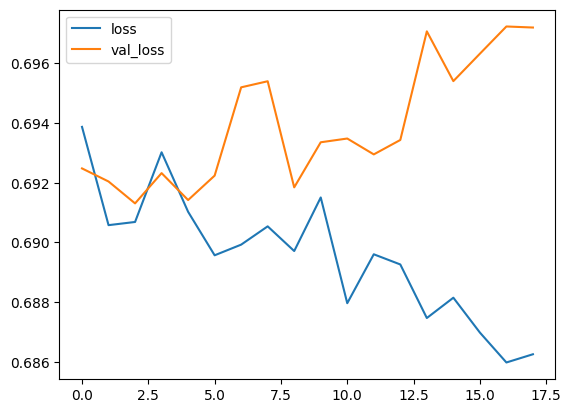

In [1827]:
history.history.keys()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


In [1828]:
# fig = plt.figure(figsize=(20,7))
# fig.add_subplot(121)

# # Accuracy
# plt.plot(history.epoch, history.history['root_mean_squared_error'], label = "rmse")
# plt.plot(history.epoch, history.history['val_root_mean_squared_error'], label = "val_rmse")

# plt.title("RMSE", fontsize=18)
# plt.xlabel("Epochs", fontsize=15)
# plt.ylabel("RMSE", fontsize=15)
# plt.grid(alpha=0.3)
# plt.legend()


# #Adding Subplot 1 (For Loss)
# fig.add_subplot(122)

# plt.plot(history.epoch, history.history['loss'], label="loss")
# plt.plot(history.epoch, history.history['val_loss'], label="val_loss")

# plt.title("Loss", fontsize=18)
# plt.xlabel("Epochs", fontsize=15)
# plt.ylabel("Loss", fontsize=15)
# plt.grid(alpha=0.3)
# plt.legend()

# plt.show()

In [1903]:
#FOR_TESTING: change and run this cell again for testing on different companies
testPredict = model.predict(testX)
print(testPredict)
print(testPredict.shape)
# testPredict = scaler.inverse_transform(testPredict)
# print(testPredict)
# testY = scaler.inverse_transform(testY.reshape(-1, 1))
print(testY)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[0.5652097 ]
 [0.56596917]
 [0.57248443]
 [0.5818543 ]
 [0.5854252 ]
 [0.57557595]
 [0.55631554]
 [0.556971  ]
 [0.5506399 ]
 [0.5477787 ]
 [0.5358529 ]
 [0.53237   ]
 [0.5300879 ]
 [0.52340496]
 [0.5225151 ]
 [0.5267976 ]
 [0.5313006 ]
 [0.52408576]
 [0.545664  ]
 [0.56907123]
 [0.5645945 ]
 [0.53406113]
 [0.5229016 ]
 [0.4927365 ]
 [0.48282546]
 [0.46633402]
 [0.4702455 ]
 [0.46407476]
 [0.46423176]
 [0.4601114 ]
 [0.46361563]
 [0.47541544]
 [0.4774522 ]
 [0.4896646 ]
 [0.4960109 ]
 [0.49595958]
 [0.509483  ]
 [0.5382798 ]
 [0.55080235]
 [0.55710363]
 [0.5589543 ]
 [0.5585443 ]
 [0.55330616]
 [0.55306536]
 [0.55066156]
 [0.5553821 ]
 [0.5575998 ]
 [0.5384026 ]
 [0.5436794 ]
 [0.5425026 ]
 [0.5499583 ]
 [0.5522474 ]
 [0.5533158 ]
 [0.54729587]
 [0.53436005]
 [0.5402171 ]
 [0.53003794]
 [0.5356998 ]
 [0.556026  ]
 [0.5650477 ]
 [0.56721246]
 [0.5717349 ]
 [0.57226413]
 [0.5890207 ]
 [0.5854773 ]
 [0.59050125]
 [0.5876769 ]
 [0.5678888 ]
 [0.5478

In [1830]:
print(testY)

[ True  True  True False False False  True  True False  True  True False
  True False False False False False False False  True  True  True False
  True False False  True  True  True False False False False  True  True
 False  True  True False  True False False  True False False  True False
 False False  True  True False False False  True  True False  True False
 False  True False  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True False  True False  True False False
  True False  True False  True False False False  True False  True  True
 False  True False  True  True  True False  True False  True False False
 False  True  True False  True  True False  True  True  True  True  True
 False  True False  True False  True  True  True False  True  True False
 False False  True False  True False False False  True  True  True False
 False False False False  True  True False False False False False False
  True  True  True  True  True False  True False  T

In [1904]:
#FOR_TESTING: change and run this cell again for testing on different companies
from sklearn.metrics import mean_squared_error, f1_score

# ###regression###
# rmse = np.sqrt(mean_squared_error(testY, testPredict))
# print(f"Root Mean Squared Error (RMSE): {rmse}")
# ###regression###

# ###binary classification###
f1_binary = f1_score(testY, [1 if p > 0.5 else 0 for p in testPredict]) # Example
print(f"F1 score: {f1_binary}")
# ###binary classification###

F1 score: 0.6333333333333333


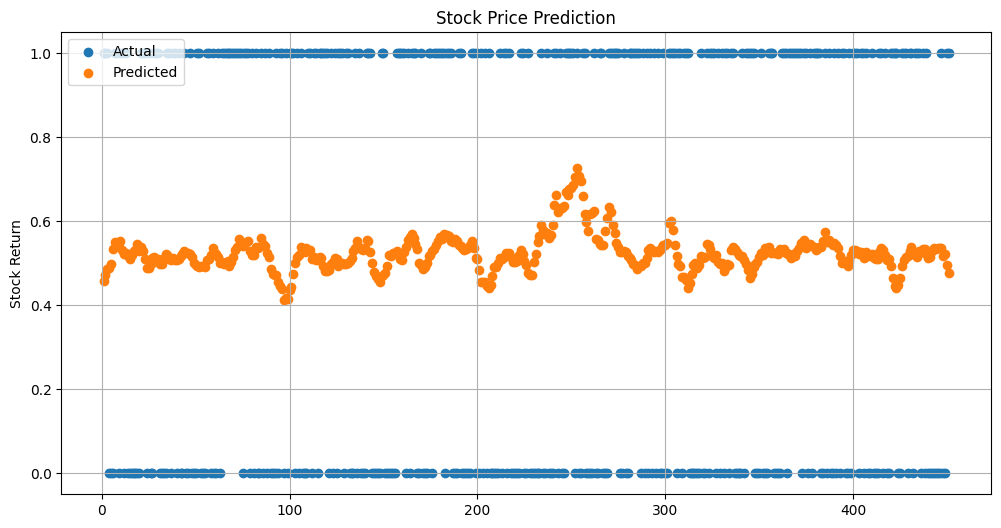

In [1832]:
plt.figure(figsize=(12, 6))
# plt.xlabel("Record")
plt.ylabel("Stock Return")
plt.title("Stock Price Prediction")
plt.scatter(np.arange(1, testY.size+1), testY, label='Actual')
plt.scatter(np.arange(1, testPredict.size+1), testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

In [1833]:
import math

## Should make the testing returns for each stock:

In [1834]:
# for df in testing_df_list:
#   df['predictedReturn'] = np.nan
#   df['isPositive'] = np.nan
#   for i in range(numberOfPreviousDaysConsidered, df.shape[0]):
#     dataInPeriod = []
#     for j in range(i-numberOfPreviousDaysConsidered,i):
#       temp = []
#       columnsOfDatasetUsed = []
#       for column in inputColumns:
#         columnsOfDatasetUsed.append(df[column][j])
#       temp.append(columnsOfDatasetUsed)
#       dataInPeriod.append(temp)
#     dataInPeriod = np.array(dataInPeriod)
#     print(dataInPeriod)
#     print(inputScaler.transform(dataInPeriod.reshape(-1, len(inputColumns))))
#     df['predictedReturn'][i] = outputScaler.inverse_transform([[model.predict(inputScaler.transform(dataInPeriod.reshape(-1, len(inputColumns))).reshape(dataInPeriod.shape))[0][0]]])[0]
#     df['isPositive'][i] = df['predictedReturn'][i] >=0
#   print(df)

#   plt.figure(figsize=(10, 8))
#   plt.plot(df['Date'], df['predictedReturn'], label = 'Predicted')
#   plt.plot(df['Date'], df['Close'], label = 'Actual')
#   plt.legend()
#   plt.show()


In [1835]:
# def takeLog(x):
#   return math.log((x*100+100)/100) #use this if it is 20% => 0.20
#   # return math.log((x+100)/100) #use this if it is 20% => 20

# def calReturnOfThePeriod(df):
#   df['logActualReturn'] = df['Daily Return'].apply(takeLog)
#   df.loc[df['isPositive'].isnull(), ['logActualReturn']] = np.nan
#   df['PredictedClose'] = (df['predictedReturn']+1)*df['Close'].shift(1)
#   returnOverPeriod = math.exp(df[df['isPositive'] == True]['logActualReturn'].sum())
#   returnOverPeriodIfNormallyInvest = math.exp(df['logActualReturn'].sum())
#   print(f'Ticker: {df['Ticker'][0]}, returnOverPeriod: {returnOverPeriod}, returnOverPeriodIfNormallyInvest: {returnOverPeriodIfNormallyInvest}, betterThanBenchMarkBy: {(returnOverPeriod-returnOverPeriodIfNormallyInvest)*100}%')
#   return {'ticker': df['Ticker'][0], 'returnOverPeriod': returnOverPeriod, 'returnOverPeriodIfNormallyInvest': returnOverPeriodIfNormallyInvest, 'betterThanBenchMarkBy': (returnOverPeriod-returnOverPeriodIfNormallyInvest)*100}

# results = []
# for i in range(len(testing_df_list)):
#   results.append(calReturnOfThePeriod(testing_df_list[i]))
#   plt.figure(i)
#   plt.plot(testing_df_list[i]['Date'], testing_df_list[i]['Close'], label = 'Actual')
#   plt.plot(testing_df_list[i]['Date'], testing_df_list[i]['PredictedClose'], label ='Predicted')
#   plt.legend()
#   plt.title(f"{testing_df_list[i]['Ticker'][0]}")
#   plt.show()


In [1836]:
# predictedReturn = pd.DataFrame(testPredict)
# predictedReturn['isPositive'] = predictedReturn > 0
# actualReturn = pd.DataFrame(testY)
# returnDf = pd.concat([predictedReturn, actualReturn], axis=1)
# returnDf.columns = ['predictedReturn', 'isPositive', 'actualReturn']
# # returnDf['predictedReturn'] = (returnDf['predictedReturn']+100)/100
# # returnDf['actualReturn'] = (returnDf['actualReturn']+100)/100
# print(returnDf)

# def takeLog(x):
#   return math.log((x*100+100)/100)

# returnDf['logActualReturn'] = returnDf['actualReturn'].apply(takeLog)
# returnOverPeriod = math.exp(returnDf[returnDf['isPositive'] == True]['logActualReturn'].sum())
# print(returnOverPeriod)

# returnOverPeriodIfNormallyInvest = math.exp(returnDf['logActualReturn'].sum())
# print(returnOverPeriodIfNormallyInvest)





## Inverse Transform Predictions

### Subtask:
Inverse transform the scaled `testPredict` and `testY` arrays back to their original return values using the `outputScaler`.


**Reasoning**:
Inverse transform the scaled predictions and actual values back to their original scale for evaluation, as specified in the subtask instructions.



In [1908]:
#FOR_TESTING: change and run this cell again for testing on different companies

###regression###
# testPredict_inverse = outputScaler.inverse_transform(testPredict)
# testY_reshaped = testY.reshape(-1, 1)
# testY_inverse = outputScaler.inverse_transform(testY_reshaped)
# testY_inverse = testY_inverse.reshape(-1)
###regression###

###binary classification###
testPredict_inverse = testPredict
testX_inverse = inputScaler.inverse_transform(testX.reshape(-1, len(inputColumns)))
testX_return = [dailyReturn[0] for dailyReturn in testX_inverse]
print(testX_inverse)
###binary classification###

print("Inverse transformed testPredict (first 5 values):\n", testPredict_inverse[:5])
print("Inverse transformed testY (first 5 values):\n", testX_return[:5])

[[-6.43166478e-03 -9.94886936e-02 -1.12223809e-03 ...  5.69129271e-01
  -1.61948799e-02  1.59233638e-02]
 [ 1.68905402e-02  1.28233836e-01  1.12017880e-02 ...  6.15401625e-01
  -2.81804666e-02  1.60302256e-02]
 [-2.66744141e-03 -2.23100369e-01 -1.92452972e-03 ...  6.04180116e-01
  -2.10747394e-02  1.59682948e-02]
 ...
 [-8.85630403e-03  1.05853769e-01  6.19671268e-03 ...  2.94939783e-01
   3.51020231e-02 -3.73567491e-02]
 [ 8.82535353e-04 -1.57053841e-01 -3.43992343e-03 ...  2.98626266e-01
   3.08497369e-02 -3.67834775e-02]
 [-2.20439293e-03  9.70001944e-02  7.65482591e-05 ...  2.94480853e-01
   2.97139217e-02 -3.61965960e-02]]
Inverse transformed testPredict (first 5 values):
 [[0.5652097 ]
 [0.56596917]
 [0.57248443]
 [0.5818543 ]
 [0.5854252 ]]
Inverse transformed testY (first 5 values):
 [np.float64(-0.006431664775884748), np.float64(0.016890540156144107), np.float64(-0.0026674414086786946), np.float64(0.005841315853680307), np.float64(-0.011631090060299276)]


**Reasoning**:
Now that the predictions and actual values are inverse-transformed, I will calculate the strategy returns and the buy-and-hold returns, then compute and visualize their cumulative returns, and finally print the total percentage returns for both strategies, as per the task requirements.



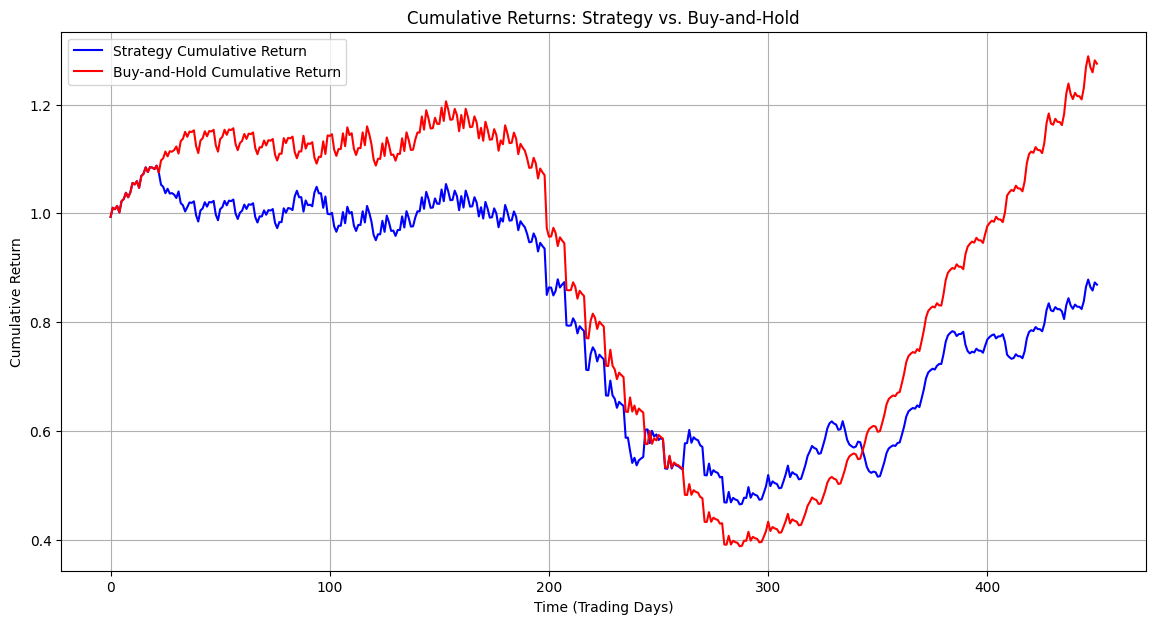

Final Strategy Return: -13.10%
Final Buy-and-Hold Return: 27.50%


In [1907]:
#FOR_TESTING: change and run this cell again for testing on different companies

strategy_returns = []
buy_and_hold_returns = []

###regression###
# for i in range(len(testPredict_inverse)):
#     # Strategy returns: if predicted return is positive, invest; otherwise, sell if you have already bought, hold cash if not yet bought.
#     if testPredict_inverse[i] > 0:
#         strategy_returns.append(testY_inverse[i])
#     else:
#         strategy_returns.append(-testY_inverse[i])

#     # Buy-and-hold returns: always use the actual return
#     buy_and_hold_returns.append(testY_inverse[i])
###regression###

###binary classification###
for i in range(len(testPredict_inverse)):
    # Strategy returns: if predicted return is positive, invest; otherwise, sell if you have already bought, hold cash if not yet bought.
    if testPredict_inverse[i] >= 0.5:
        strategy_returns.append(testX_return[i])
    else:
        strategy_returns.append(-testX_return[i])

    # Buy-and-hold returns: always use the actual return
    buy_and_hold_returns.append(testX_return[i])
###binary classification###

# Convert to numpy arrays for easier calculation
strategy_returns = np.array(strategy_returns)
buy_and_hold_returns = np.array(buy_and_hold_returns)

# Calculate cumulative returns
cumulative_strategy_returns = np.cumprod(1 + strategy_returns)
cumulative_buy_and_hold_returns = np.cumprod(1 + buy_and_hold_returns)

# Plotting cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(cumulative_strategy_returns, label='Strategy Cumulative Return', color='blue')
plt.plot(cumulative_buy_and_hold_returns, label='Buy-and-Hold Cumulative Return', color='red')
plt.title('Cumulative Returns: Strategy vs. Buy-and-Hold')
plt.xlabel('Time (Trading Days)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Calculate final percentage returns
final_strategy_return_percent = (cumulative_strategy_returns[-1] - 1) * 100
final_buy_and_hold_return_percent = (cumulative_buy_and_hold_returns[-1] - 1) * 100

print(f"Final Strategy Return: {final_strategy_return_percent:.2f}%")
print(f"Final Buy-and-Hold Return: {final_buy_and_hold_return_percent:.2f}%")

In [1839]:
from google.colab import drive
import joblib
sessionDriveLocation = '/content/gdrive'
drive.mount(sessionDriveLocation)
modelSavingLocation = '/MyDrive/FYP/InvestmentService/'
fileName = 'fypLSTM.h5'
model.save(sessionDriveLocation+modelSavingLocation+fileName)
scalersSavingLocation = '/MyDrive/FYP/InvestmentService/'
inputScalerFileName = 'inputScaler.joblib'
joblib.dump(inputScaler, sessionDriveLocation+scalersSavingLocation+inputScalerFileName)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


['/content/gdrive/MyDrive/FYP/InvestmentService/inputScaler.joblib']